In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import random
import time
import math
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

#import benchmarks
import time
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import precision_recall_fscore_support
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score,KFold
from sklearn.ensemble import BaggingClassifier
data = pd.read_csv('heart.csv')
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [3]:
X = data.iloc[:,:13].values
Y = data['target'].values
print(X.shape)
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3)
sc=StandardScaler()
X_train=sc.fit_transform(X_train)
X_test=sc.fit_transform(X_test)

(1025, 13)


In [4]:
#Applying SVM classification without data processing
svcclassifier =BaggingClassifier(base_estimator=DecisionTreeClassifier(),n_estimators=100,max_samples=0.8,oob_score=True)
#svcclassifier =SVC(C=1.0,kernel = 'poly')
svcclassifier.fit(X_train, y_train)
y_pred = svcclassifier.predict(X_test)
P = accuracy_score(y_pred,y_test)
print("Accuracy score for SVM:",P)

Accuracy score for SVM: 0.961038961038961


In [5]:
import numpy  as np
import random
import os
Convergence_curve=[]
from scipy.special import gamma

############################################################################

# Function
# def target_function(variables_values):
#     x1, x2     = variables_values
#     func_value = -np.cos(x1) * np.cos(x2) * np.exp(-(x1 - np.pi) ** 2 - (x2 - np.pi) ** 2)
#     return func_value
    
import math
def target_function(x):
    dim=len(x);

    w=[i for i in range(len(x))]
    o=0
    for i in range(0,dim):
        
        #o+=(x[i]+0.5)**2
        ##f10#a=x[i]**2
        ##f10#b=math.cos(2*22/7*x[i])
        #f8#o+=-x[i]*math.sin((abs(x[i]))**0.5)
    ##f10#o+=-20*math.exp(-0.2*(a/dim)**0.5)-math.exp(b/dim)+20
        #o+=((100*(x[i+1]-x[i]**2))**2+(x[i]-1)**2)
        #o+=-x[i]*math.sin((abs(x[i]))**0.5)
        #f9#o+=(x[i]**2-10*math.cos(2*22/7*x[i])+10)
        #o+=(x[i]**2-(10*math.cos(2*22/7*x[i]))+10)
        #o+=i*x[i]**4+random.uniform(0,1)
        #f4#o+=max(abs(x[i]),0<=i<=dim)
        #f7#o+=i*x[i]**4+os.urandom(0,1)
        
    #o=np.sum(w*(x**4))+np.random.uniform(0,1);
   # print(o)
    #o=abs(sum(x )/ (((sum(x)**2) + 1))**0.5)
        o+=-x[i]*math.sin((abs(x[i]))**0.5)
    

    return o;

############################################################################

# Function: Initialize Variables
def initial_variables(size = 5, min_values = [-10]*12, max_values = [10]*12, target_function = target_function):
    position = np.zeros((size, len(min_values)+1))
    #Convergence_curve=[]
    for i in range(0, size):
        for j in range(0, len(min_values)):
             position[i,j] = random.uniform(min_values[j], max_values[j])
        position[i,-1] = target_function(position[i,:-1])
    return position
#Convergence_curve=np.zeros(Max_iter)
# Function: Distance Calculations
def euclidean_distance(x, y):
    distance = 0
    for j in range(0, len(x)):
        distance = (x[j] - y[j])**2 + distance       
    return distance**(1/2) 

# Function: Levy Distribution
def levy_flight(beta = 1.5):
    beta    = beta  
    r1      = int.from_bytes(os.urandom(8), byteorder = "big") / ((1 << 64) - 1)
    r2      = int.from_bytes(os.urandom(8), byteorder = "big") / ((1 << 64) - 1)
    sig_num = gamma(1+beta)*np.sin((np.pi*beta)/2.0)
    sig_den = gamma((1+beta)/2)*beta*2**((beta-1)/2)
    sigma   = (sig_num/sig_den)**(1/beta)
    levy    = (0.01*r1*sigma)/(abs(r2)**(1/beta))
    return levy

# Function: SAC
def separation_alignment_cohesion(dragonflies, radius, dragon = 0):
    dimensions = 0
    neighbours = 0
    index_list = []
    separation = np.zeros((1, dragonflies.shape[1]-1))
    alignment  = np.zeros((1, dragonflies.shape[1]-1))
    cohesion   = np.zeros((1, dragonflies.shape[1]-1))
    i          = dragon
    for j in range(0, dragonflies.shape[0]):
        if (i != j):
            for k in range(0, dragonflies.shape[1]-1):
                x  = dragonflies[i,0:dragonflies.shape[1]-1]
                y  = dragonflies[j,0:dragonflies.shape[1]-1]
                nd = euclidean_distance(x, y)
                if (nd < radius[0,k]):
                    dimensions      = dimensions + 1
                    separation[0,k] = separation[0,k] - dragonflies[i,k] - dragonflies[i,k]
                    alignment [0,k] = alignment [0,k] + dragonflies[j,k]
                    cohesion  [0,k] = cohesion  [0,k] + dragonflies[j,k]
            if (dimensions == dragonflies.shape[1] - 1):
                neighbours = neighbours + 1
                index_list.append(j)
    if (neighbours > 0):
        alignment = alignment/neighbours
        cohesion  = cohesion/neighbours
        for m in range(0, len(index_list)): 
            for n in range(0, dragonflies.shape[1]-1):
                cohesion[0,n] = cohesion[0,n] - dragonflies[index_list[m],n]                
    return separation, alignment, cohesion, neighbours

# Function: Update Food
def update_food(dragonflies, radius, food_position, min_values = [-10]*12, max_values = [10]*12, dragon = 0, target_function = target_function):
    dimensions = 0 
    i          = dragon       
    x          = food_position[0,:-1]
    y          = dragonflies[i,:-1]
    fd         = euclidean_distance(x, y)
    for k in range(0, dragonflies.shape[1]-1):
        if (fd <= radius[0,k]):
            dimensions = dimensions + 1
    if (dimensions == dragonflies.shape[1] - 1):
        for k in range(0, dragonflies.shape[1]-1):
            food_position[0,k] = np.clip(food_position[0,k] - dragonflies[i,k], min_values[k], max_values[k])
    else:
        food_position[0,k] = 0           
    food_position[0,-1] = target_function(food_position[0,:-1])
    return food_position, dimensions

# Function: Update Predator
def update_predator(dragonflies, radius, predator, min_values = [-10]*12, max_values = [10]*12, dragon = 0, target_function = target_function):
    dimensions = 0
    i          = dragon 
    x          = predator[0,:-1]
    y          = dragonflies[i,0:dragonflies.shape[1]-1]
    pd         = euclidean_distance(x, y)
    for k in range(0, dragonflies.shape[1]-1):
        if (pd <= radius[0,k]):
            dimensions = dimensions + 1
    if (dimensions == dragonflies.shape[1]):
        for k in range(0, dragonflies.shape[1]-1):
            predator[0,k] = np.clip(predator[0,k] + dragonflies[i,k], min_values[k], max_values[k])  
    else:
        predator[0,k] = 0
    predator[0,-1] = target_function(predator[0,0:predator.shape[1]-1])
    return predator

# Function: Update Search Matrices
def update_da(adjustment_const, weight_inertia, delta_max, dragonflies, best_dragon, radius, food_position, predator, delta_flies, min_values, max_values, target_function):
    #print(dragonflies,food_position)
    rand1             = int.from_bytes(os.urandom(8), byteorder = "big") / ((1 << 64) - 1)
    rand2             = int.from_bytes(os.urandom(8), byteorder = "big") / ((1 << 64) - 1)
    rand3             = int.from_bytes(os.urandom(8), byteorder = "big") / ((1 << 64) - 1)
    rand4             = int.from_bytes(os.urandom(8), byteorder = "big") / ((1 << 64) - 1)
    weight_separation = 2*rand1*adjustment_const # Seperation Weight
    weight_alignment  = 2*rand2*adjustment_const # Alignment Weight
    weight_cohesion   = 2*rand3*adjustment_const # Cohesion Weight
    weight_food       = 2*rand4                  # Food Attraction Weight
    weight_predator   = 1*adjustment_const       # Enemy distraction Weight     
    for i in range(0, dragonflies.shape[0]):
        separation, alignment, cohesion, neighbours = separation_alignment_cohesion(dragonflies, radius, i)
        food_position, dimensions                   = update_food(dragonflies, radius, food_position, min_values, max_values, i, target_function)
        predator                                    = update_predator(dragonflies, radius, predator, min_values, max_values, i, target_function)
        if (dimensions > 0):
            if (neighbours >= 1):
                for j in range(0, len(min_values)):
                    r1               = int.from_bytes(os.urandom(8), byteorder = "big") / ((1 << 64) - 1)
                    r2               = int.from_bytes(os.urandom(8), byteorder = "big") / ((1 << 64) - 1)
                    r3               = int.from_bytes(os.urandom(8), byteorder = "big") / ((1 << 64) - 1)
                    delta_flies[i,j] = np.clip(weight_inertia*delta_flies[i,j] + r1*alignment[0, j] + r2*cohesion[0, j] + r3*separation[0, j], -delta_max[0,j], delta_max[0,j])
                    dragonflies[i,j] = dragonflies[i,j] + delta_flies[i,j]
            elif(neighbours < 1):
                for k in (0, dragonflies.shape[1]-1):
                    dragonflies[i,k] = dragonflies[i,k] + levy_flight(beta = 1.5)
                    delta_flies[i,k] = 0
        elif(dimensions == 0):
            for m in range(0, len(min_values)):
                delta_flies[i,m] = np.clip((weight_separation*separation[0,m] + weight_alignment*alignment[0,m] + weight_cohesion*cohesion[0,m]  + weight_food*food_position[0,m] + weight_predator*predator[0,m]) + weight_inertia*delta_flies[i,m], -delta_max[0,m], delta_max[0,m])
                dragonflies[i,m] = np.clip(dragonflies[i,m] + delta_flies[i,m], min_values[m], max_values[m])     
        dragonflies[i,-1] = target_function(dragonflies[i,:-1])
    for i in range (0, dragonflies.shape[0]):   
        if (dragonflies[i,-1] < food_position[0,-1]):
            for j in range(0, dragonflies.shape[1]):
                food_position[0,j] = dragonflies[i,j]
        if (dragonflies[i,-1] > predator[0,-1]):
            for j in range(0, dragonflies.shape[1]):
                predator[0,j] = dragonflies[i,j]  
    if (food_position[food_position[:,-1].argsort()][0,:][-1] < best_dragon[-1]):
        best_dragon = np.copy(food_position[food_position[:,-1].argsort()][0,:]) 
    else:
        for j in range(0, food_position.shape[1]):
            food_position[0,j] = best_dragon[j]
    return dragonflies, food_position, predator, delta_flies, best_dragon

############################################################################
  
# DA Function
def dragonfly_algorithm(size = 5, min_values = [-10]*12, max_values = [10]*12, generations = 100, target_function = target_function, verbose = True):
    max_accuracy=[]
    #Convergence_curve=[]
    FIT=[]
    #np.zeros(generations)
    fea_list=[]
    i_ind=0
    s=0
    t=0
    X_train1, X_test1, y_train1, y_test1 = train_test_split(X, Y, test_size = 0.30,stratify=Y)
    radius    = np.zeros((1, len(min_values)))
    delta_max = np.zeros((1, len(min_values)))
    for j in range(0, len(min_values)):
        radius[0,j]    = (max_values[j] - min_values[j])/10
        delta_max[0,j] = (max_values[j] - min_values[j])/10
    dragonflies   = initial_variables(size, min_values, max_values, target_function)
    delta_flies   = initial_variables(size, min_values, max_values, target_function)   
    predator      = initial_variables(1,    min_values, max_values, target_function)
    food_position = initial_variables(1,    min_values, max_values, target_function)   
    count         = 0
    l=[]
    for i in range (0, dragonflies.shape[0]):   
        if (dragonflies[i,-1] < food_position[0,-1]):
            for j in range(0, dragonflies.shape[1]):
                food_position[0,j] = dragonflies[i,j]
        if (dragonflies[i,-1] > predator[0,-1]):
            for j in range(0, dragonflies.shape[1]):
                predator[0,j] = dragonflies[i,j]          
    best_dragon = np.copy(food_position[food_position[:,-1].argsort()][0,:])   
    while (count <= generations):
        X_train2=[]
        X_test2=[]
                    # if (verbose == True):    
        #     print('Generation: ', count, ' f(x) = ', best_dragon[-1])
        for j in range(0, len(min_values)):
            radius[0,j]    = (max_values[j] - min_values[j])/4 + ((max_values[j] - min_values[j])*(count/generations)*2)
            weight_inertia   = 0.9 - count*((0.5)/generations)        
            adjustment_const = 0.1 - count*((0.1)/(generations/2))
        if (adjustment_const < 0):
            adjustment_const = 0
        dragonflies, food_position, predator, delta_flies, best_dragon = update_da(adjustment_const, weight_inertia, delta_max, dragonflies, best_dragon, radius, food_position, predator, delta_flies, min_values, max_values, target_function)
        count = count + 1
        #@#@#
        #Convergence_curve[l]=best_dragon;
        if (verbose == True):
            #print('Iteration = ', count,  ' f(x) = ', best_dragon)
#             modified_data=pd.DataFrame();
#             for z in range(0,13):
#                 if(best_dragon[z]>=-0.05):
#                     #print()
#                     modified_data[data.columns[z]]=data[data.columns[z]].astype(float)
#             X_train1, X_test1, y_train1, y_test1 = train_test_split(modified_data, Y, test_size = 0.30,stratify=Y)
#             X_train1=sc.fit_transform(X_train1)
#             X_test1=sc.fit_transform(X_test1)

#             svcclassifier.fit(X_train1, y_train1)
#             y_pred1 = svcclassifier.predict(X_test1)
#             P1=accuracy_score(y_pred1,y_test1)
#             FIT=0.7*(1-P)+0.3*(len(modified_data.columns)/13)
#             print(FIT,P1,end=' ')
#             l.append(P1)
#             print(P1*100,end=' ')
#             print(modified_data.columns,len(modified_data.columns))
#     print(best_dragon)
#     print(max(l),"At iteration :",l.index(max(l)))
#     return best_dragon
            modified_data=pd.DataFrame();
        dummy=[]
        print(best_dragon)
        for z in range(0,13):
            if(best_dragon[z]>=-0.05):
                dummy.append(1)
                modified_data[data.columns[z]]=data[data.columns[z]].astype(float)
                X_train2.append(list(X_train1[:,z]))
                X_test2.append(list(X_test1[:,z]))
            else:
                dummy.append(0)
        fea_list.append(dummy) 
        X_train2=np.transpose(X_train2)
        X_test2=np.transpose(X_test2)
        s=s+(len(modified_data.columns)/13)
        X_train2=sc.fit_transform(X_train2)
        X_test2=sc.fit_transform(X_test2)
        start = time.time()
        print(X_train1.shape)
        svcclassifier.fit(X_train2, y_train1)
        end = time.time()
        y_pred1 = svcclassifier.predict(X_test2)
        P1=accuracy_score(y_pred1,y_test1)
        kf=KFold(n_splits=10)
        score=cross_val_score(svcclassifier,X,Y,cv=kf)
        print("Cross Validation Scores are {}".format(score),"Mean is",score.mean())
        print("Modified Accuracy score for SVM at "+str(count)+" Iteration", P1)
        print("Selected columns",modified_data.columns)
        #print("Fitness is ",Convergence_curve[count])
        cm1 = confusion_matrix(y_test1, y_pred1)
        print(cm1)
        print(precision_recall_fscore_support(y_test1, y_pred1, average='macro'))
        t=t+(end - start)
        max_accuracy.append(P1)
        #fit_curve.append(0.7*(P1)+(0.3*(13-len(modified_data.columns)/len(modified_data.columns))))
        FIT.append(0.9*(1-P1)+0.1*(len(modified_data.columns)/13))
    print("^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^")
    print("1 THE AVERAGE OF CLASSIFICATION ACCURACY",sum(max_accuracy)/100)
    print("2 THE AVERAGE OF SELECTED FEATURE",s/100)
    print("3 THE MEAN FITNESS FUNCTION",sum(FIT)/100)
    print("4 THE BEST FITNESS FUNCTION",min(FIT))
    print("5 THE WORST FITNESS FUNCTION",max(FIT))
    print("6 AVERAGE COMPUTIONAL TIME",t/100)
    print("Mean of each selected feature")
    numpy_list=np.array(fea_list)
    #print("Maximum Accuracy",max(max_accuracy),"At Iteration",max_accuracy.index(max(max_accuracy))+1)
    for me in range(0,13):
        print((sum(numpy_list[:,me]))/100,end=" ")
    print()
    print("SD of each selected feature")
    print(np.std(numpy_list,axis=0))
    return max_accuracy,FIT,best_dragon

In [6]:
min_values = [-10]*1
min_values

[-10]

In [7]:
#Convergence_curve=[]
#print(dragonfly_algorithm())
#dragonfly_algorithm()
max_accuracy,c,best_dragonn=dragonfly_algorithm()
print("@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@\n")
print("Maximum Accuracy",max(max_accuracy),"At Iteration",max_accuracy.index(max(max_accuracy))+1)


[  1.43692605  -2.3606981    7.11501188  -5.39493732   5.773812
  -0.47148491   2.55531591   8.27192697  -0.32493625   3.22083575
   1.50951678   9.51934273 -11.52368406]
(717, 13)
Cross Validation Scores are [1.         1.         1.         1.         1.         1.
 1.         1.         0.97058824 1.        ] Mean is 0.9970588235294118
Modified Accuracy score for SVM at 1 Iteration 0.9707792207792207
Selected columns Index(['age', 'cp', 'chol', 'restecg', 'thalach', 'oldpeak', 'slope', 'ca'], dtype='object')
[[146   4]
 [  5 153]]
(0.9707048551060868, 0.9708438818565401, 0.9707641196013289, None)
[  1.43692605  -2.3606981    7.11501188  -5.39493732   5.773812
  -0.47148491   2.55531591   8.27192697  -0.32493625   3.22083575
   1.50951678   9.51934273 -11.52368406]
(717, 13)
Cross Validation Scores are [1.         1.         1.         1.         0.97087379 1.
 1.         1.         0.97058824 1.        ] Mean is 0.9941462021701885
Modified Accuracy score for SVM at 2 Iteration 0.957

Cross Validation Scores are [1.         1.         1.         1.         1.         1.
 1.         1.         0.97058824 1.        ] Mean is 0.9970588235294118
Modified Accuracy score for SVM at 15 Iteration 0.9772727272727273
Selected columns Index(['age', 'cp', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak',
       'slope', 'ca'],
      dtype='object')
[[148   2]
 [  5 153]]
(0.9772085178157284, 0.9775105485232067, 0.9772667362582903, None)
[  2.61487215  -4.51231043   6.          -8.87135682   6.
   4.72901383   5.06551584   6.           1.10796634   6.
   3.0488546    2.         -26.42063179]
(717, 13)
Cross Validation Scores are [1.         1.         1.         1.         1.         1.
 1.         1.         0.97058824 1.        ] Mean is 0.9970588235294118
Modified Accuracy score for SVM at 16 Iteration 0.961038961038961
Selected columns Index(['age', 'cp', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak',
       'slope', 'ca'],
      dtype='object')
[[145   5]
 

Cross Validation Scores are [1.         1.         1.         1.         1.         1.
 1.         1.         0.97058824 1.        ] Mean is 0.9970588235294118
Modified Accuracy score for SVM at 29 Iteration 0.9772727272727273
Selected columns Index(['age', 'cp', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak',
       'slope', 'ca'],
      dtype='object')
[[148   2]
 [  5 153]]
(0.9772085178157284, 0.9775105485232067, 0.9772667362582903, None)
[  6.          -6.09279312   6.          -6.           6.
   3.63768798   6.           6.           5.60871866   6.
   6.           1.06452519 -27.43975984]
(717, 13)
Cross Validation Scores are [1.         1.         1.         1.         1.         1.
 1.         1.         0.97058824 0.98039216] Mean is 0.9950980392156863
Modified Accuracy score for SVM at 30 Iteration 0.9675324675324676
Selected columns Index(['age', 'cp', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak',
       'slope', 'ca'],
      dtype='object')
[[145   5]


Cross Validation Scores are [1.         1.         1.         1.         0.97087379 1.
 1.         1.         0.97058824 1.        ] Mean is 0.9941462021701885
Modified Accuracy score for SVM at 43 Iteration 0.9642857142857143
Selected columns Index(['age', 'cp', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak',
       'slope', 'ca'],
      dtype='object')
[[146   4]
 [  7 151]]
(0.9642209572000844, 0.9645147679324895, 0.9642762998344563, None)
[  6.          -6.09279312   6.          -6.           6.
   3.63768798   6.           6.           5.60871866   6.
   6.           1.06452519 -27.43975984]
(717, 13)
Cross Validation Scores are [1.         1.         1.         1.         1.         1.
 1.         1.         0.97058824 1.        ] Mean is 0.9970588235294118
Modified Accuracy score for SVM at 44 Iteration 0.961038961038961
Selected columns Index(['age', 'cp', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak',
       'slope', 'ca'],
      dtype='object')
[[145   5]
 

Cross Validation Scores are [1.         1.         1.         1.         1.         1.
 1.         1.         0.97058824 1.        ] Mean is 0.9970588235294118
Modified Accuracy score for SVM at 57 Iteration 0.9512987012987013
Selected columns Index(['age', 'cp', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak',
       'slope', 'ca'],
      dtype='object')
[[142   8]
 [  7 151]]
(0.9513528344096914, 0.951181434599156, 0.9512570819661754, None)
[  6.          -6.09279312   6.          -6.           6.
   3.63768798   6.           6.           5.60871866   6.
   6.           1.06452519 -27.43975984]
(717, 13)
Cross Validation Scores are [1.         1.         1.         1.         1.         1.
 1.         1.         0.97058824 1.        ] Mean is 0.9970588235294118
Modified Accuracy score for SVM at 58 Iteration 0.9707792207792207
Selected columns Index(['age', 'cp', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak',
       'slope', 'ca'],
      dtype='object')
[[146   4]
 

Cross Validation Scores are [1.         1.         1.         1.         1.         1.
 1.         1.         0.97058824 1.        ] Mean is 0.9970588235294118
Modified Accuracy score for SVM at 70 Iteration 0.9448051948051948
Selected columns Index(['age', 'cp', 'trestbps', 'chol', 'restecg', 'thalach', 'exang',
       'oldpeak', 'slope'],
      dtype='object')
[[144   6]
 [ 11 147]]
(0.9449082858950032, 0.9451898734177215, 0.9447999578303727, None)
[  6.067459    -4.02805486   4.70814236   0.27318387   4.95078479
  -0.32542077   4.88474863   4.26461573   5.42958055   4.69169335
   3.86910091 -15.69391011 -38.47448828]
(717, 13)
Cross Validation Scores are [1.         1.         1.         1.         1.         1.
 1.         1.         0.97058824 1.        ] Mean is 0.9970588235294118
Modified Accuracy score for SVM at 71 Iteration 0.961038961038961
Selected columns Index(['age', 'cp', 'trestbps', 'chol', 'restecg', 'thalach', 'exang',
       'oldpeak', 'slope'],
      dtype='object'

Cross Validation Scores are [1.         1.         1.         1.         1.         1.
 1.         1.         0.97058824 1.        ] Mean is 0.9970588235294118
Modified Accuracy score for SVM at 83 Iteration 0.9545454545454546
Selected columns Index(['age', 'cp', 'trestbps', 'chol', 'restecg', 'thalach', 'exang',
       'oldpeak', 'slope'],
      dtype='object')
[[147   3]
 [ 11 147]]
(0.9551898734177215, 0.9551898734177215, 0.9545454545454545, None)
[  6.067459    -4.02805486   4.70814236   0.27318387   4.95078479
  -0.32542077   4.88474863   4.26461573   5.42958055   4.69169335
   3.86910091 -15.69391011 -38.47448828]
(717, 13)
Cross Validation Scores are [1.         1.         1.         1.         1.         1.
 1.         1.         0.97058824 1.        ] Mean is 0.9970588235294118
Modified Accuracy score for SVM at 84 Iteration 0.9577922077922078
Selected columns Index(['age', 'cp', 'trestbps', 'chol', 'restecg', 'thalach', 'exang',
       'oldpeak', 'slope'],
      dtype='object

Cross Validation Scores are [1.         1.         1.         1.         1.         1.
 1.         1.         0.97058824 1.        ] Mean is 0.9970588235294118
Modified Accuracy score for SVM at 96 Iteration 0.9383116883116883
Selected columns Index(['age', 'cp', 'trestbps', 'chol', 'restecg', 'thalach', 'exang',
       'oldpeak', 'slope'],
      dtype='object')
[[142   8]
 [ 11 147]]
(0.9382458359687962, 0.9385232067510548, 0.9382954269867883, None)
[  6.067459    -4.02805486   4.70814236   0.27318387   4.95078479
  -0.32542077   4.88474863   4.26461573   5.42958055   4.69169335
   3.86910091 -15.69391011 -38.47448828]
(717, 13)
Cross Validation Scores are [1.         1.         1.         1.         1.         1.
 1.         1.         0.97058824 0.98039216] Mean is 0.9950980392156863
Modified Accuracy score for SVM at 97 Iteration 0.9512987012987013
Selected columns Index(['age', 'cp', 'trestbps', 'chol', 'restecg', 'thalach', 'exang',
       'oldpeak', 'slope'],
      dtype='object

Text(0, 0.5, 'Accuracy')

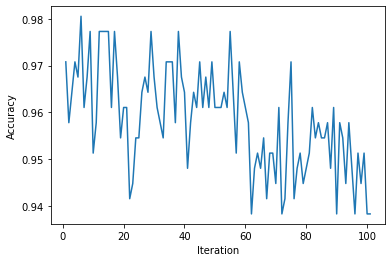

In [8]:
import matplotlib.pyplot as plt
l=[i+1 for i in range(0,101)]
plt.plot(l,max_accuracy)
plt.xlabel('Iteration')
plt.ylabel('Accuracy')

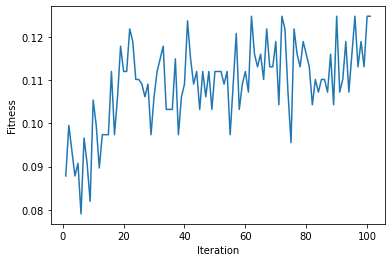

In [9]:
#Convergence-Curve
import matplotlib.pyplot as plt
l=[i+1 for i in range(0,101)]
plt.plot(l,c)
plt.xlabel('Iteration')
plt.ylabel('Fitness')
plt.show()

In [10]:
s1=[1/(1+math.exp(-2*item)) for item in best_dragonn]
s2=[1/(1+math.exp(-1*item)) for item in best_dragonn]
s3=[1/(1+math.exp(-1*item/2)) for item in best_dragonn]
s4=[1/(1+math.exp(-1*item/3)) for item in best_dragonn]
v1=[abs(math.erf((((math.pi)**0.5)/2)*item)) for item in best_dragonn]
v2=[abs(math.tanh(item)) for item in best_dragonn]
v3=[abs(item/(1+item*2)*0.5) for item in best_dragonn]
v4=[abs((2/math.pi)*math.atan((2/math.pi)*item)) for item in best_dragonn]

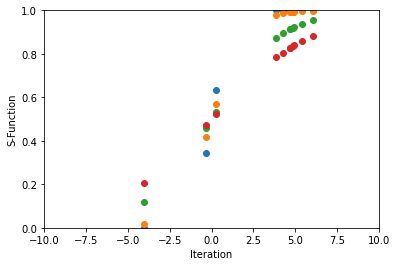

In [11]:
plt.ylim(0, 1)
plt.xlim(-10, 10)
# plt.plot(alpha,s1)
# plt.plot(alpha,s2)
# plt.plot(alpha,s3)
# plt.plot(alpha,s4)
plt.scatter(best_dragonn,s1)
plt.scatter(best_dragonn,s2)
plt.scatter(best_dragonn,s3)
plt.scatter(best_dragonn,s4)

plt.xlabel('Iteration')
plt.ylabel('S-Function')
plt.show()

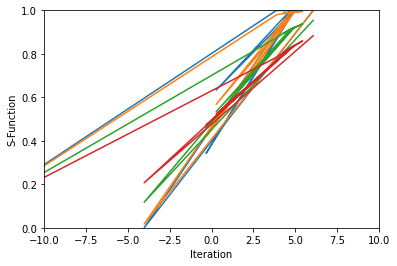

In [12]:
plt.ylim(0, 1)
plt.xlim(-10, 10)
plt.plot(best_dragonn,s1)
plt.plot(best_dragonn,s2)
plt.plot(best_dragonn,s3)
plt.plot(best_dragonn,s4)
# plt.scatter(alpha,s1)
# plt.scatter(alpha,s2)
# plt.scatter(alpha,s3)
# plt.scatter(alpha,s4)

plt.xlabel('Iteration')
plt.ylabel('S-Function')
plt.show()

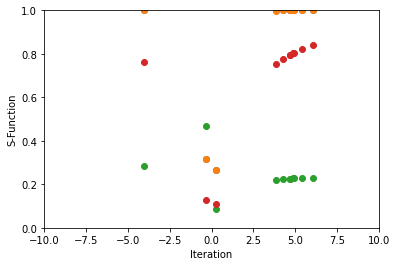

In [13]:
plt.ylim(0, 1)
plt.xlim(-10, 10)
plt.scatter(best_dragonn,v1)
plt.scatter(best_dragonn,v2)
plt.scatter(best_dragonn,v3)
plt.scatter(best_dragonn,v4)
# plt.plot(alpha,v1)
# plt.plot(alpha,v2)
# plt.plot(alpha,v3)
# plt.plot(alpha,v4)
plt.xlabel('Iteration')
plt.ylabel('S-Function')
plt.show()

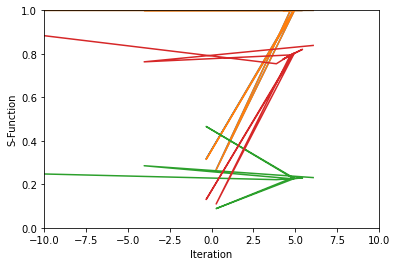

In [14]:
plt.ylim(0, 1)
plt.xlim(-10, 10)
# plt.scatter(alpha,v1)
# plt.scatter(alpha,v2)
# plt.scatter(alpha,v3)
# plt.scatter(alpha,v4)
plt.plot(best_dragonn,v1)
plt.plot(best_dragonn,v2)
plt.plot(best_dragonn,v3)
plt.plot(best_dragonn,v4)
plt.xlabel('Iteration')
plt.ylabel('S-Function')
plt.show()